In [26]:
import os
import sys
import threading
import datetime
import glob

import tkinter as tk
from tkinter import ttk, filedialog, messagebox

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers
from tensorflow.keras.preprocessing import image as kp_image
from tensorflow.keras.applications import VGG16, Xception
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from PIL import Image, ImageTk, ImageDraw, ImageFont
import cv2
import xml.etree.ElementTree as ET
from lxml import etree
from sklearn.preprocessing import LabelBinarizer

In [47]:
im_path = r"C:\Users\sagar\images\images\*\*.jpg"  # insert your image path
xml_path = r"C:\Users\sagar\label\*.xml"   #insert your label paths
PARENT_FOLDER = 'C:/Users/sagar/RandomRecipePicker/starter_files/images/images'  # give folder name which stores image
ground_truth_folder = "label"  # give name of folder which stores ground truth labels
save_dir = model_dir = history_dir = "retrained_models"# it stores the location where you want to store retrained labels
save_predictedlabloc="sagarnewlabel"    #it stores new labels so name as perference
mode = "Vgg"    # retraining is only done for vgg moodel you can change it  "Xception" to train it xcep
bg_colour = "#3d6466"
accuracy_column = "class_accuracy"
history_filename = "TrainingHistory.csv"
selected_folder = None   
image_list = []
current_index = 0
img_tk = None
image_label = None 
zoom_scale = 1.0       
selected_vgg_model = None
selected_xcep_model = None
last_n_epochs = 5    # accuracy to determine which model is better is done by averg of last 5 epochs
UNCERTAINTY_THRESHOLD = 1.0 # threshold for uncertainty 
BAR_WIDTH = 200
BAR_HEIGHT = 20
MIN_ZOOM, MAX_ZOOM = 0.2, 5.0
ZOOM_IN_FACTOR = 1.25
ZOOM_OUT_FACTOR = 0.8
batch_size = 32    
train_split = 0.8
warning_shown = False
stop_training_event = threading.Event()
training_thread = None

In [28]:
def plot_old_new_history_side_by_side(old_hist, new_hist, old_name='Old Model', new_name='New Model'):
    metrics = old_hist.columns.tolist()
    num_metrics = len(metrics)
    fig, axes = plt.subplots(num_metrics, 2, figsize=(14, num_metrics * 3))

    for i, metric in enumerate(metrics):
        axes[i, 0].plot(np.arange(len(old_hist[metric])), old_hist[metric])
        axes[i, 0].set_title(f'{old_name} - {metric}')
        axes[i, 0].set_xlabel('Epoch')
        axes[i, 0].set_ylabel(metric)

        axes[i, 1].plot(np.arange(len(new_hist[metric])), new_hist[metric])
        axes[i, 1].set_title(f'{new_name} - {metric}')
        axes[i, 1].set_xlabel('Epoch')
        axes[i, 1].set_ylabel(metric)

    fig.tight_layout()
    return fig

In [29]:
# Mappings
class_map_vgg16 = {
    'crescent_gap': 1, 'crease': 2, 'silk_spot': 3,
    'water_spot': 4, 'welding_line': 5, 'inclusion': 6,
    'oil_spot': 7, 'waist folding': 8, 'rolled_pit': 9,
    'punching_hole': 10
}
class_dictvgg16 = {v: k for k, v in class_map_vgg16.items()}

# =========================
# Shared State Container
# =========================
class SharedState:
    def __init__(self):
        self.imageu = None
        self.vgg_result = None
        self.xcep_result = None
        self.vgg_grad = None
        self.xcep_grad = None
        self.vgg_uncertainty = None
        self.xcep_uncertainty = None

shared_state = SharedState()

def clear_widgets(frame):
    for widget in frame.winfo_children():
        widget.destroy()

In [56]:
def xcepfun(location):
    base_model = tf.keras.applications.Xception(
        weights=None,
        include_top=False,
        input_shape=(224, 224, 3),
        pooling='avg'
    )

    base_model.trainable = True

    inputs = keras.Input(shape=(224, 224, 3))
    x = base_model(inputs)

    x1 = keras.layers.Dense(1024, activation="relu")(x)
    x1 = keras.layers.Dropout(0.5)(x1)
    x1 = keras.layers.Dense(512, activation="relu")(x1)
    x1 = keras.layers.Dropout(0.5)(x1)
    out1 = keras.layers.Dense(1, name="xmin")(x1)
    out2 = keras.layers.Dense(1, name="ymin")(x1)
    out3 = keras.layers.Dense(1, name="xmax")(x1)
    out4 = keras.layers.Dense(1, name="ymax")(x1)

    x2 = keras.layers.Dense(1024, activation="relu")(x)
    x2 = keras.layers.Dropout(0.5)(x2)
    x2 = keras.layers.Dense(512, activation="relu")(x2)
    x2 = keras.layers.Dropout(0.5)(x2)
    out_class = keras.layers.Dense(10, activation="softmax", name="class")(x2)

    model = keras.models.Model(inputs=inputs, outputs=[out1, out2, out3, out4, out_class])
    model.load_weights(location)
    return model
    
def vggfun(location):
    base_model = tf.keras.applications.VGG16(
        weights=None,
        include_top=False,
        input_shape=(224, 224, 3),
        pooling='avg'
    )

    base_model.trainable = True

    inputs = keras.Input(shape=(224, 224, 3))
    x = base_model(inputs)

    x1 = keras.layers.Dense(1024, activation="relu")(x)
    x1 = keras.layers.Dropout(0.5)(x1)
    x1 = keras.layers.Dense(512, activation="relu")(x1)
    x1 = keras.layers.Dropout(0.5)(x1)
    out1 = keras.layers.Dense(1, name="xmin")(x1)
    out2 = keras.layers.Dense(1, name="ymin")(x1)
    out3 = keras.layers.Dense(1, name="xmax")(x1)
    out4 = keras.layers.Dense(1, name="ymax")(x1)

    x2 = keras.layers.Dense(1024, activation="relu")(x)
    x2 = keras.layers.Dropout(0.5)(x2)
    x2 = keras.layers.Dense(512, activation="relu")(x2)
    x2 = keras.layers.Dropout(0.5)(x2)
    out_class = keras.layers.Dense(10, activation="softmax", name="class")(x2)

    model = keras.models.Model(inputs=inputs, outputs=[out1, out2, out3, out4, out_class])
    model.load_weights(location)
    return model            


def ML_modelfun(mode, location):
    if mode == "Vgg":
        return vggfun(location)
    elif mode == "Xception":
        return xcepfun(location)
    else:
        raise ValueError(f"Invalid model mode: {mode}")   

In [50]:
def build_model(num_classes=10, mode="Vgg"):
    if mode == "Vgg":
        base = tf.keras.applications.VGG16(weights=None, include_top=False,
                                           input_shape=(224,224,3), pooling='avg')
    elif mode == "Xception":
        base = tf.keras.applications.Xception(weights=None, include_top=False,
                                              input_shape=(224,224,3), pooling='avg')
    else:
        raise ValueError("mode must be 'Vgg' or 'Xception'")

    base.trainable = True
    inputs = keras.Input((224,224,3))
    x = base(inputs)

    # Bounding box branch
    x1 = keras.layers.Dense(1024, activation="relu")(x)
    x1 = keras.layers.Dropout(0.5)(x1)
    x1 = keras.layers.Dense(512, activation="relu")(x1)
    x1 = keras.layers.Dropout(0.5)(x1)

    out1 = keras.layers.Dense(1, name="xmin")(x1)
    out2 = keras.layers.Dense(1, name="ymin")(x1)
    out3 = keras.layers.Dense(1, name="xmax")(x1)
    out4 = keras.layers.Dense(1, name="ymax")(x1)

    # Classification branch
    x2 = keras.layers.Dense(1024, activation="relu")(x)
    x2 = keras.layers.Dropout(0.5)(x2)
    x2 = keras.layers.Dense(512, activation="relu")(x2)
    x2 = keras.layers.Dropout(0.5)(x2)
    out_class = keras.layers.Dense(num_classes, activation="softmax", name="class")(x2)

    model = keras.models.Model(inputs=inputs, outputs=[out1, out2, out3, out4, out_class])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0003),
        loss={
            'xmin': 'mse',
            'ymin': 'mse',
            'xmax': 'mse',
            'ymax': 'mse',
            'class': 'categorical_crossentropy'
        },
        metrics={
            'xmin': 'mae',
            'ymin': 'mae',
            'xmax': 'mae',
            'ymax': 'mae',
            'class': 'accuracy'
        }
    )

    return model

# =========================
# Data Processing
# =========================

def to_labels(xml_path):
    xml = open(xml_path).read()
    sel = etree.HTML(xml)
    width = int(sel.xpath("//size/width/text()")[0])
    height = int(sel.xpath("//size/height/text()")[0])
    xmin = int(sel.xpath("//bndbox/xmin/text()")[0])
    ymin = int(sel.xpath("//bndbox/ymin/text()")[0])
    xmax = int(sel.xpath("//bndbox/xmax/text()")[0])
    ymax = int(sel.xpath("//bndbox/ymax/text()")[0])
    return [xmin/width, ymin/height, xmax/width, ymax/height]

def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img,3)
    img = tf.image.resize(img,[224,224])
    img = tf.cast(img,tf.float32) / 255.0
    return img

def ground_class(parent_folder, base_name):
    found = []
    for sub in os.listdir(parent_folder):
        subp = os.path.join(parent_folder, sub)
        if os.path.isdir(subp) and os.path.exists(os.path.join(subp, base_name + ".jpg")):
            found.append(sub)
    return found or []
#........................................................ make changes in image paths and label paths.......................................
def get_dataset(im_path: str = r"C:\Users\sagar\images\images\*\*.jpg", 
                label_path: str = r"C:\Users\sagar\label\*.xml",
                batch_size: int = 32, 
                train_share: float = 0.8,
                verbose: bool = True):
    image_path = glob.glob(im_path)
    xmls_path = glob.glob(label_path)

    print(f'Found {len(image_path)} images and {len(xmls_path)} paths')



    xmls_path.sort(key = lambda x:x.split("/")[-1].split(".xml")[0])
    image_path.sort(key = lambda x:x.split("/")[-1].split(".jpg")[0])

    # xmls_train = [path.split("/")[-1].split(".")[0] for path in xmls_path]
    xmls_train = [os.path.splitext(os.path.basename(path))[0] for path in xmls_path]

    imgs_train = [
        img for img in image_path
        if os.path.splitext(os.path.basename(img))[0] in xmls_train
    ]
    # imgs_train = [img for img in image_path if os.path.splitext(os.path.basename(img))[0] in xmls_train]
    # imgs_train = [img for img in image_path if img.split("/")[-1].split(".jpg")[0] in xmls_train]
    print(f'Found {len(imgs_train)} images_train and {len(xmls_train)} paths_train')
    labels = [os.path.basename(os.path.dirname(label)) for label in imgs_train]
    # labels = [label.split("/")[-2] for label in imgs_train]
    labels = pd.DataFrame(labels, columns = ["Defect Type"])

    # Obtain training labels without duplication
    Class = labels["Defect Type"].unique()
    # Store data values in key:value pairs with Python dictionaries
    Class_dict = dict(zip(Class, range(1,len(Class) + 1)))
    labels["Class"] = labels["Defect Type"].apply(lambda x: Class_dict[x])

    lb = LabelBinarizer()
    # Fit label binarizer
    lb.fit(list(Class_dict.values()))
    # Convert multi-class labels to binary labels (belong or does not belong to the class)
    transformed_labels = lb.transform(labels["Class"])
    y_bin_labels = []

    for i in range(transformed_labels.shape[1]):
        y_bin_labels.append("Class" + str(i))
        labels["Class" + str(i + 1)] = transformed_labels[:, i]


    labels.drop("Class", axis = 1, inplace = True)
    labels.drop("Defect Type", axis = 1, inplace = True)

    coors = [to_labels(path) for path in xmls_path]


    xmin, ymin, xmax, ymax = list(zip(*coors))

    # Convert to Numpy array
    xmin = np.array(xmin)
    ymin = np.array(ymin)
    xmax = np.array(xmax)
    ymax = np.array(ymax)
    label = np.array(labels.values, dtype = np.float16)


    labels_dataset = tf.data.Dataset.from_tensor_slices((xmin, ymin, xmax, ymax, label))


    dataset = tf.data.Dataset.from_tensor_slices(imgs_train)
    dataset = dataset.map(load_image)

    dataset_label = tf.data.Dataset.zip((dataset, labels_dataset))

    dataset_label = dataset_label.repeat().shuffle(500).batch(batch_size)

    # Creates a Dataset that prefetches elements from this dataset
    # Most dataset input pipelines should end with a call to prefetch
    # This allows later elements to be prepared while the current element is being processed
    # This often improves latency and throughput, at the cost of using additional memory to store prefetched elements

    dataset_label = dataset_label.prefetch(tf.data.experimental.AUTOTUNE)


    train_count = int(len(imgs_train) * train_share)
    test_count = int(len(imgs_train) * (1 - train_share))

    train_dataset = dataset_label.skip(test_count)
    test_dataset = dataset_label.take(test_count)
    return train_dataset, test_dataset, Class_dict, train_count, test_count

# =========================
# Callbacks & Training
# =========================
#..............................................................make changes in label path and xml path........
def train_model(model, callback_update, save_path, mode="Vgg"):
    global test_dataset
    test_dataset=[]
    train_dataset, test_dataset, class_dict, train_count, test_count = get_dataset(
        im_path=im_path,
        label_path=xml_path,
        batch_size=batch_size,
        train_share=train_split,
    )
    lr_reduce = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=5, factor=0.5, min_lr=1e-6)
    now = datetime.datetime.now().strftime("%Y%m%d_%H%M")
    if save_path is None:
        now = datetime.datetime.now().strftime("%Y%m%d_%H%M")
        save_path = f"{mode.lower()}_{now}.h5"

    os.makedirs(save_dir, exist_ok=True)
    full_save_path = os.path.join(save_dir, save_path)
    checkpoint = keras.callbacks.ModelCheckpoint(
        filepath=full_save_path,
        save_best_only=True,
        monitor='val_loss',
        mode='min'
    )

    
    class CancelableConsoleLogger(keras.callbacks.Callback):
        def on_epoch_end(self, epoch, logs=None):
            if callback_update:
                msg = f"Epoch {epoch+1}: " + ", ".join([f"{k}={v:.4f}" for k, v in logs.items()])
                callback_update(msg)

            # 🔴 Check cancel event
            if stop_training_event.is_set():
                print("🛑 Training cancellation requested. Stopping...")
                self.model.stop_training = True


    history = model.fit(
        train_dataset,
        steps_per_epoch=train_count // batch_size,
        validation_data=test_dataset,
        validation_steps=test_count // batch_size,
        epochs=1,
        callbacks=[checkpoint, CancelableConsoleLogger()]
    )

    # now = datetime.datetime.now().strftime("%Y%m%d_%H%M")
    pd.DataFrame(history.history).to_csv(os.path.join(save_dir, f'TrainingHistory_{now}.csv'), index=False)

In [32]:
#frame 1 functions
# =========================
# IMAGE SELECTION
# =========================
def open_single_image():
    """Open a dialog to select a single image and set the global image list."""
    global selected_folder, image_list, current_index

    image_path = filedialog.askopenfilename(
        title="Select a single image",
        filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp *.tiff")]
    )

    if image_path:
        selected_folder = os.path.dirname(image_path)
        image_list = [image_path]
        current_index = 0
        print(f"Selected image: {image_path}")
    else:
        # Clear previous selection
        selected_folder = None
        image_list = []
        current_index = 0
        print("No image selected.")


# =========================
# GRADIENT COMPUTATION (Grad-CAM)
# =========================
def compute_grads(model, ims):
    """
    Compute gradients of the predicted class score with respect to input image.
    Returns model outputs and gradients.
    """
    with tf.GradientTape() as tape:
        tape.watch(ims)
        result = model(ims)
        max_idx = tf.argmax(result[4], axis=1)
        max_score = result[4][0, max_idx[0]]

    grads = tape.gradient(max_score, ims)
    return result, grads


# =========================
# MONTE CARLO DROPOUT PREDICTION
# =========================
def mc_predict(model, x, num_samples=20):
    """
    Perform Monte Carlo Dropout predictions to estimate uncertainty.
    Returns bounding box means, uncertainties, predicted classes, and class uncertainties.
    """
    class_preds, x_min_preds, y_min_preds, x_max_preds, y_max_preds = [], [], [], [], []

    for _ in range(num_samples):
        x_min, y_min, x_max, y_max, pred_class = model(x, training=True)
        class_preds.append(pred_class)
        x_min_preds.append(x_min)
        y_min_preds.append(y_min)
        x_max_preds.append(x_max)
        y_max_preds.append(y_max)

    # Convert to numpy arrays
    class_preds = np.array(class_preds)
    x_min_preds = np.array(x_min_preds)
    y_min_preds = np.array(y_min_preds)
    x_max_preds = np.array(x_max_preds)
    y_max_preds = np.array(y_max_preds)

    # Compute mean predictions and uncertainties
    pred_classes = [elem.argmax() for elem in class_preds.mean(axis=0)]
    pred_std = class_preds.std(axis=0)
    pred_un = [pred_std[i][c] for i, c in enumerate(pred_classes)]

    return (
        x_min_preds.mean(axis=0), x_min_preds.std(axis=0),
        y_min_preds.mean(axis=0), y_min_preds.std(axis=0),
        x_max_preds.mean(axis=0), x_max_preds.std(axis=0),
        y_max_preds.mean(axis=0), y_max_preds.std(axis=0),
        pred_classes, pred_un
    )


# =========================
# PREDICTION WITH BOTH MODELS
# =========================
def predict_with_both_models():
    global img_tensor
    """Run prediction and uncertainty estimation using VGG16 and Xception models."""
    if not image_list:
        print("No image selected.")
        return

    image_path = image_list[0]
    print(f"Running predictions on: {image_path}")

    img_tensor = load_image(image_path)
    img_tensor = tf.expand_dims(img_tensor, axis=0)# Ensure load_image() is defined

    # Prediction using VGG16
    pred_vgg, grads_vgg = compute_grads(vgg16, img_tensor)
    x_min_pred_vgg, _, y_min_pred_vgg, _, x_max_pred_vgg, _, y_max_pred_vgg, _, pred_classes_vgg, pred_un_vgg = mc_predict(vgg16, img_tensor, 20)

    # Prediction using Xception
    pred_xcep, grads_xcep = compute_grads(Xception, img_tensor)
    x_min_pred_xcep, _, y_min_pred_xcep, _, x_max_pred_xcep, _, y_max_pred_xcep, _, pred_classes_xcep, pred_un_xcep = mc_predict(Xception, img_tensor, 20)

    # Store both results in shared_state
    shared_state.imageu = img_tensor
    shared_state.vgg_result = [x_min_pred_vgg, y_min_pred_vgg, x_max_pred_vgg, y_max_pred_vgg, pred_classes_vgg]
    shared_state.xcep_result = [x_min_pred_xcep, y_min_pred_xcep, x_max_pred_xcep, y_max_pred_xcep, pred_classes_xcep]
    shared_state.vgg_grad = grads_vgg
    shared_state.xcep_grad = grads_xcep
    shared_state.vgg_uncertainty = pred_un_vgg[0]
    shared_state.xcep_uncertainty = pred_un_xcep[0]

    print("Prediction done.")

def plot_accuracy_popup():
    folder = filedialog.askdirectory(title="Select 'retrained model' Folder")
    if not folder:
        return

    csv_files = sorted([f for f in os.listdir(folder) if f.endswith(".csv")])
    if not csv_files:
        messagebox.showerror("Error", "No .csv files found in the selected folder.")
        return

    model_names = []
    accuracies = []

    for csv_file in csv_files:
        file_path = os.path.join(folder, csv_file)
        try:
            df = pd.read_csv(file_path)
            if accuracy_column not in df.columns:
                continue
            avg_acc = df[accuracy_column].tail(last_n_epochs).mean()
            model_names.append(os.path.splitext(csv_file)[0])  # Remove .csv
            accuracies.append(avg_acc)
        except Exception:
            continue

    if not model_names:
        messagebox.showwarning("No Valid Files", f"No valid .csv files with '{accuracy_column}' found.")
        return

    # Create new popup window
    popup = tk.Toplevel()
    popup.title("Class Accuracy Plot")
    popup.geometry("1000x500")

    # Create matplotlib figure
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(model_names, accuracies, marker='o', linestyle='-', linewidth=2)
    ax.set_title(f"Retrained Models - Avg Class Accuracy (Last {last_n_epochs} Epochs)")
    ax.set_xlabel("Model Name (CSV Filename)")
    ax.set_ylabel("Class Accuracy")
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=45, ha='right')
    ax.set_ylim(0, 1)
    ax.grid(True)
    fig.tight_layout()

    # Embed the figure in the popup window
    canvas = FigureCanvasTkAgg(fig, master=popup)
    canvas.draw()
    canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)
 

In [33]:
#frame 1 UI
def load_frame1():
    clear_widgets(frame2)
    frame1.tkraise()
    frame1.pack_propagate(False)

    for widget in frame1.winfo_children():
        widget.destroy()

    frame1.grid_rowconfigure(0, weight=1)
    frame1.grid_rowconfigure(1, weight=1)
    frame1.grid_rowconfigure(2, weight=2)
    frame1.grid_rowconfigure(3, weight=1)
    frame1.grid_columnconfigure(0, weight=1)
    frame1.grid_columnconfigure(1, weight=1)

    # Title
    tk.Label(
        frame1, text="Upload the data",
        bg=bg_colour, fg="white",
        font=("Arial", 44, "bold")
    ).grid(row=0, column=0, columnspan=2, pady=(40, 20))

    # Subtitle
    tk.Label(
        frame1, text="Select Trained Models and Image",
        bg=bg_colour, fg="white",
        font=("Arial", 24)
    ).grid(row=1, column=0, columnspan=2, pady=(10, 30))

    # Model selection section
    model_frame = tk.Frame(frame1, bg=bg_colour)
    model_frame.grid(row=2, column=0, columnspan=2, pady=10)

    tk.Label(model_frame, text="Select VGG16 model (.h5):", bg=bg_colour, fg="white", font=("Arial", 14)).grid(row=0, column=0, padx=10, pady=10, sticky='e')
    vgg_model_combo = ttk.Combobox(model_frame, width=40, state="readonly")
    vgg_model_combo.grid(row=0, column=1, padx=10, pady=10)

    tk.Label(model_frame, text="Select Xception model (.h5):", bg=bg_colour, fg="white", font=("Arial", 14)).grid(row=1, column=0, padx=10, pady=10, sticky='e')
    xcep_model_combo = ttk.Combobox(model_frame, width=40, state="readonly")
    xcep_model_combo.grid(row=1, column=1, padx=10, pady=10)

    tk.Label(model_frame, text="Select Old Model History (.csv):", bg=bg_colour, fg="white", font=("Arial", 14)).grid(row=2, column=0, padx=10, pady=10, sticky='e')
    vgg_hist_combo = ttk.Combobox(model_frame, width=40, state="readonly")
    vgg_hist_combo.grid(row=2, column=1, padx=10, pady=10)

    tk.Label(model_frame, text="Select New Model History (.csv):", bg=bg_colour, fg="white", font=("Arial", 14)).grid(row=3, column=0, padx=10, pady=10, sticky='e')
    xcep_hist_combo = ttk.Combobox(model_frame, width=40, state="readonly")
    xcep_hist_combo.grid(row=3, column=1, padx=10, pady=10)
    


    # Populate models
    vgg_files = sorted([f for f in os.listdir(model_dir) if f.startswith("vgg") and f.endswith(".h5")])
    xcep_files = sorted([f for f in os.listdir(model_dir) if f.startswith("xception") and f.endswith(".h5")])
    vgg_model_combo["values"] = vgg_files
    xcep_model_combo["values"] = xcep_files

    if vgg_files:
        vgg_model_combo.current(len(vgg_files) - 1)
    if xcep_files:
        xcep_model_combo.current(len(xcep_files) - 1)
        
    # Populate history dropdowns from retrained/
    hist_files = sorted([f for f in os.listdir(history_dir) if f.endswith(".csv")])
    vgg_hist_combo["values"] = hist_files
    xcep_hist_combo["values"] = hist_files
    if hist_files:
        vgg_hist_combo.current(0)
        xcep_hist_combo.current(len(hist_files) - 1)

    # Predict Button
    def start_prediction():
        global selected_vgg_model, selected_xcep_model, vgg16, Xception
        vgg_model = vgg_model_combo.get()
        xcep_model = xcep_model_combo.get()

        if not vgg_model or not xcep_model:
            messagebox.showwarning("Model Missing", "Please select both VGG and Xception models.")
            return

        selected_vgg_model = os.path.join(model_dir, vgg_model)
        selected_xcep_model = os.path.join(model_dir, xcep_model)

        vgg16 =vggfun(selected_vgg_model)
        Xception = xcepfun(selected_xcep_model)
        open_single_image()
        if not image_list:
            print("Prediction aborted. No image selected.")
            return
        predict_with_both_models()
        load_frame2()
        
    def compare_histories():
        vgg_hist_path = os.path.join(history_dir, vgg_hist_combo.get())
        xcep_hist_path = os.path.join(history_dir, xcep_hist_combo.get())
    
        try:
            vgg_hist = pd.read_csv(vgg_hist_path)
            xcep_hist = pd.read_csv(xcep_hist_path)
            metrics = [col for col in vgg_hist.columns if col in xcep_hist.columns]
    
            # Create scrollable popup window
            popup = tk.Toplevel(frame1)
            popup.title("Training History Comparison")
            popup.geometry("1200x800")
    
            canvas = tk.Canvas(popup)
            scrollbar = tk.Scrollbar(popup, orient="vertical", command=canvas.yview)
            scroll_frame = tk.Frame(canvas)
    
            scroll_frame.bind(
                "<Configure>",
                lambda e: canvas.configure(scrollregion=canvas.bbox("all"))
            )
    
            canvas.create_window((0, 0), window=scroll_frame, anchor="nw")
            canvas.configure(yscrollcommand=scrollbar.set)
    
            canvas.pack(side="left", fill="both", expand=True)
            scrollbar.pack(side="right", fill="y")
    
        
            for metric in metrics:
                fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    
                # VGG plot
                ax[0].plot(vgg_hist[metric])
                ax[0].set_title(f"VGG16 - {metric}")
                ax[0].set_xlabel("Epoch")
                ax[0].set_ylabel(metric)
    
                # Xception plot
                ax[1].plot(xcep_hist[metric])
                ax[1].set_title(f"Xception - {metric}")
                ax[1].set_xlabel("Epoch")
                ax[1].set_ylabel(metric)
    
                fig.tight_layout()
    
                plot_canvas = FigureCanvasTkAgg(fig, master=scroll_frame)
                plot_canvas.draw()
                plot_canvas.get_tk_widget().pack(pady=10)
                plt.close(fig) 
    
            # Close button
            tk.Button(scroll_frame, text="Close", command=popup.destroy).pack(pady=10)
    
        except Exception as e:
            messagebox.showerror("Error", f"Failed to compare histories:\n{e}")

    compare_hist_btn = tk.Button(
        frame1,
        text="Compare Training Histories",
        font=("Arial", 12, "bold"),
        bg="#1f3f49", fg="white",
        command=compare_histories
    )
    compare_hist_btn.grid(row=5, column=0, columnspan=2, pady=10)
    
    plot_button = tk.Button(
        frame1,
        text="Model ImproveMent (Class Accuracy) (All Retrained Models)",
        font=("Arial", 12, "bold"),
        bg="#1f3f49", fg="white",
        command=plot_accuracy_popup
    )
    plot_button.grid(row=6, column=0, columnspan=2, pady=(10, 20))

    tk.Button(
        frame1,
        text="Open Image & Predict (VGG16 + Xception)",
        font=("Arial", 16, "bold"),
        bg="#1f3f49", fg="white",
        cursor="hand2", activebackground="#4ca6a8", activeforeground="white",
        command=start_prediction,
        padx=20, pady=10
    ).grid(row=3, column=0, columnspan=2, pady=40)

In [34]:
#frame 2 functions
# Function to load image and draw boxes
def load_image_with_boxes(index, zoom=1.0):
    if not image_list:
        return None

    img_path = image_list[index]
    base_name = os.path.splitext(os.path.basename(img_path))[0]
    image_pil = keras.preprocessing.image.array_to_img(shared_state.imageu[0])
    base_size = 224
    zoomed_size = int(base_size * zoom)
    image_resized = image_pil.resize((zoomed_size, zoomed_size))

    draw = ImageDraw.Draw(image_resized)
    font_size = max(12, int(20 * zoom))
    try:
        font = ImageFont.truetype("arial.ttf", font_size)
    except:
        font = ImageFont.load_default()

    pred_class_namev = pred_class_namex = None

    if shared_state.vgg_result:
        x_min, y_min, x_max, y_max, class_index = shared_state.vgg_result
        coords = [x_min.item(), y_min.item(), x_max.item(), y_max.item()]
        coords = [c * zoomed_size for c in coords]
        pred_class_namev = class_dictvgg16[class_index[0] + 1]
        draw.rectangle(coords, outline="#FF0000", width=2)

    if shared_state.xcep_result:
        x_min, y_min, x_max, y_max, class_index = shared_state.xcep_result
        coords = [x_min.item(), y_min.item(), x_max.item(), y_max.item()]
        coords = [c * zoomed_size for c in coords]
        pred_class_namex = class_dictvgg16[class_index[0] + 1]
        draw.rectangle(coords, outline="#0000FF", width=2)

    gt_label_path = os.path.join(ground_truth_folder, base_name + ".xml")
    gt_class_names = []
    if os.path.exists(gt_label_path):
        global grimg
        out1, out2, out3, out4 = to_labels(gt_label_path)
        grimg=[out1, out2, out3, out4]
        coords = [out1 * zoomed_size, out2 * zoomed_size, out3 * zoomed_size, out4 * zoomed_size]
        gt_class_names = ground_class(PARENT_FOLDER, base_name)
        draw.rectangle(coords, outline="#00FF00", width=2)

    return ImageTk.PhotoImage(image_resized), pred_class_namev, pred_class_namex, gt_class_names

# Function to generate saliency overlay
def generate_saliency_image(alpha1=0.5, alpha2=0.5, brightness=0.6, display_size=(400, 400)):
    if shared_state.imageu is None or shared_state.vgg_grad is None or shared_state.xcep_grad is None:
        return None

    image_np = shared_state.imageu[0].numpy()
    grads_vgg = shared_state.vgg_grad[0].numpy()
    grads_xcep = shared_state.xcep_grad[0].numpy()

    saliency_vgg = np.max(np.abs(grads_vgg), axis=-1)
    saliency_xcep = np.max(np.abs(grads_xcep), axis=-1)

    if np.all(saliency_vgg == 0):
        return ImageTk.PhotoImage(Image.fromarray((image_np * 255).astype(np.uint8)))

    saliency_vgg = (saliency_vgg - saliency_vgg.min()) / (saliency_vgg.max() - saliency_vgg.min() + 1e-8)
    saliency_xcep = (saliency_xcep - saliency_xcep.min()) / (saliency_xcep.max() - saliency_xcep.min() + 1e-8)

    saliency_vgg *= brightness
    dimmed_img = image_np * brightness

    cmap_vgg = plt.get_cmap('jet')
    cmap_xcep = plt.get_cmap('hot')
    sal_color_vgg = cmap_vgg(saliency_vgg)[..., :3]
    sal_color_xcep = cmap_xcep(saliency_xcep)[..., :3]
    overlay = dimmed_img + (sal_color_vgg * alpha1) + (sal_color_xcep * alpha2)
    overlay = np.clip(overlay, 0, 1)

    img_pil = Image.fromarray((overlay * 255).astype(np.uint8)).resize(display_size)
    return ImageTk.PhotoImage(img_pil)

In [35]:
#frame 2
def load_frame2():
    clear_widgets(frame1)
    frame2.tkraise()
    frame2.pack_propagate(False)
    frame2.grid_rowconfigure(0, weight=1)
    frame2.grid_columnconfigure(0, weight=1)
    frame2.grid_columnconfigure(1, weight=0)

    def get_uncertainty_color(value):
        r = int(255 * (value / 100.0))
        g = int(255 * (1 - value / 100.0))
        return f'#{r:02x}{g:02x}00'

    def create_rounded_rect(canvas, x1, y1, x2, y2, radius=10, **kwargs):
        points = [
            x1+radius, y1, x2-radius, y1, x2, y1, x2, y1+radius,
            x2, y2-radius, x2, y2, x2-radius, y2, x1+radius, y2,
            x1, y2, x1, y2-radius, x1, y1+radius, x1, y1
        ]
        return canvas.create_polygon(points, smooth=True, **kwargs)

    def zoom_main(factor):
        global zoom_scale
        zoom_scale = max(0.2, min(zoom_scale * factor, 5.0))
        update_image()

    # def show_warning_popup(msg):
    #     popup = tk.Toplevel()
    #     popup.title("High Uncertainty Warning")
    #     popup.configure(bg="orange")
    #     tk.Label(popup, text=msg, bg="orange", fg="black", font=("Arial", 12, "bold"), wraplength=300, justify="center").pack(pady=20)
    #     tk.Button(popup, text="OK", command=popup.destroy).pack(pady=5)

    def draw_uncertainty_bar(canvas, percent, color):
        canvas.delete("all")
        filled = int(BAR_WIDTH * (percent / 100))
        create_rounded_rect(canvas, 0, 0, BAR_WIDTH, BAR_HEIGHT, radius=10, fill="gray", outline="")
        create_rounded_rect(canvas, 0, 0, filled, BAR_HEIGHT, radius=10, fill=color, outline="")
        canvas.create_text(BAR_WIDTH//2, BAR_HEIGHT//2, text=f"{percent:.1f}%", fill="white", font=("Arial", 10, "bold"))

    def update_image():
        global img_tk, pred_classv, pred_classx, gt_classes, warning_shown
        if not image_list:
            return

        img_tk, pred_classv, pred_classx, gt_classes = load_image_with_boxes(current_index, zoom=zoom_scale)
        if image_label and image_label.winfo_exists():
            image_label.config(image=img_tk)
        image_label.image = img_tk

        if pred_class_labelvg and pred_class_labelvg.winfo_exists():
            pred_class_labelvg.config(text=f"Predicted Vgg16: {pred_classv}")
        if pred_class_labelxc and pred_class_labelxc.winfo_exists():
            pred_class_labelxc.config(text=f"Predicted Xception: {pred_classx}")
        gt_class_label.config(text=f"Ground Truth: {', '.join(gt_classes) if gt_classes else 'N/A'}")

        if shared_state.vgg_uncertainty is not None and shared_state.xcep_uncertainty is not None:
            percent_vgg = shared_state.vgg_uncertainty * 100
            percent_xcep = shared_state.xcep_uncertainty * 100

            if (percent_vgg > UNCERTAINTY_THRESHOLD or percent_xcep > UNCERTAINTY_THRESHOLD) and not warning_shown:
                warning_shown = True
                messagebox.showwarning("High Uncertainty", "Uncertainty for this image is high.\nPlease consider relabeling it.")

            draw_uncertainty_bar(vgg_bar, percent_vgg, get_uncertainty_color(percent_vgg))
            draw_uncertainty_bar(xcep_bar, percent_xcep, get_uncertainty_color(percent_xcep))

    def open_saliency_window():
        if shared_state.vgg_grad is None or shared_state.imageu is None or shared_state.xcep_grad is None:
            return

        popup = tk.Toplevel()
        popup.title("Saliency Map Viewer")
        popup.geometry("600x750")
        popup.configure(bg=bg_colour)

        sal_img_label = tk.Label(popup, bg=bg_colour)
        sal_img_label.pack()

        alpha1 = tk.DoubleVar(value=0.5)
        alpha2 = tk.DoubleVar(value=0.5)

        def update_saliency(*args):
            sal_img = generate_saliency_image(alpha1.get(), alpha2.get())
            sal_img_label.config(image=sal_img)
            sal_img_label.image = sal_img

        tk.Label(popup, text="Alpha (Vgg16)", fg="white", bg=bg_colour).pack(pady=(10, 0))
        tk.Scale(popup, from_=0, to=1, resolution=0.05, orient="horizontal", variable=alpha1, command=update_saliency).pack()
        tk.Label(popup, text="Alpha (Xception)", fg="white", bg=bg_colour).pack(pady=(10, 0))
        tk.Scale(popup, from_=0, to=1, resolution=0.05, orient="horizontal", variable=alpha2, command=update_saliency).pack()

        update_saliency()
    def save_predicted_labels():
        base_name = os.path.splitext(os.path.basename(image_list[current_index]))[0]
        label_path = os.path.join(save_predictedlabloc, base_name + ".txt")
        os.makedirs(save_predictedlabloc, exist_ok=True)
        
         # Prevent overwriting
        if os.path.exists(label_path):
            messagebox.showwarning("Exists", f"Label for {base_name} already exists. Skipping save.")
            return
        orig_img = keras.preprocessing.image.array_to_img(shared_state.imageu[0])
        with open(label_path, 'w') as f:
            for result, class_dict in [(shared_state.vgg_result, class_dictvgg16), (shared_state.xcep_result, class_dictvgg16)]:
                if result:
                    x_min, y_min, x_max, y_max, class_index = result
                    cls_id = class_index[0]
                    xmin = x_min.item()
                    ymin = y_min.item()
                    xmax = x_max.item()
                    ymax = y_max.item()
                    f.write(f"{cls_id} {xmin:.6f} {ymin:.6f} {xmax:.6f} {ymax:.6f}\n")
        
                    ## Save image to existing class folder
                    class_name = class_dict[cls_id + 1]
                    class_folder = os.path.join(PARENT_FOLDER, class_name)
                    os.makedirs(class_folder, exist_ok=True)
                    save_image_path = os.path.join(class_folder, base_name + ".jpg")

                    if os.path.exists(save_image_path):
                        messagebox.showwarning("Exists", f"Image {base_name}.jpg already exists in {class_name}. Skipping save.")
                        return

                    orig_img.save(save_image_path)
        
        messagebox.showinfo("Saved", f"Predicted labels saved for {base_name}.")

    def relabel_image():
        # Temporarily disable zoom on frame2 to avoid conflict with popup
        frame2.unbind_all("<MouseWheel>")
        # Temporarily disable zoom on frame2 to avoid conflict with popup
        frame2.unbind_all("<MouseWheel>")
        if not image_list:
            return

        orig_img = keras.preprocessing.image.array_to_img(shared_state.imageu[0])
        w, h = orig_img.size

        relabel_popup = tk.Toplevel()
        relabel_popup.title("Relabel Image")
        zoom_factor = 1.0

        def resize_image():
            new_w, new_h = int(w * zoom_factor), int(h * zoom_factor)
            return orig_img.resize((new_w, new_h))

        img_display = resize_image()
        popup_width = img_display.width + 40
        popup_height = img_display.height + 200
        relabel_popup.geometry(f"{popup_width}x{popup_height}")
        relabel_popup.configure(bg=bg_colour)

        canvas_frame = tk.Frame(relabel_popup)
        canvas_frame.pack(fill="both", expand=True, padx=10, pady=10)

        vbar = tk.Scrollbar(canvas_frame, orient="vertical")
        vbar.pack(side="right", fill="y")
        hbar = tk.Scrollbar(canvas_frame, orient="horizontal")
        hbar.pack(side="bottom", fill="x")

        canvas = tk.Canvas(
            canvas_frame,
            width=w,
            height=h,
            yscrollcommand=vbar.set,
            xscrollcommand=hbar.set,
            cursor="cross",
            bg="black"
        )
        canvas.pack(side="left", fill="both", expand=True)

        vbar.config(command=canvas.yview)
        hbar.config(command=canvas.xview)

        tk.Label(relabel_popup, text="Left-click and drag to draw boxes", bg=bg_colour, fg="white").pack()
        tk.Label(relabel_popup, text="Select Class:", bg=bg_colour, fg="white").pack()

        class_names = list(class_dictvgg16.values())
        class_combo = ttk.Combobox(relabel_popup, values=class_names, state="readonly")
        class_combo.current(0)
        class_combo.pack(pady=5)

        boxes = []
        start_x = start_y = rect = None

        img_display = resize_image()
        img_tk = ImageTk.PhotoImage(img_display)
        image_id = canvas.create_image(0, 0, anchor="nw", image=img_tk)
        canvas.config(scrollregion=(0, 0, img_display.width, img_display.height))

        def redraw_boxes():
            canvas.delete("box")
            for box in boxes:
                x1, y1, x2, y2, cls_id = box
                canvas.create_rectangle(x1, y1, x2, y2, outline="cyan", width=2, tags="box")
                class_text = class_names[cls_id] if 0 <= cls_id < len(class_names) else str(cls_id)
                canvas.create_text(x1 + 5, y1 + 10, text=class_text, fill="cyan", anchor="nw", font=("Arial", 12), tags="box")

        def update_canvas_image():
            nonlocal img_display, img_tk
            img_display = resize_image()
            img_tk = ImageTk.PhotoImage(img_display)
            canvas.itemconfig(image_id, image=img_tk)
            canvas.config(scrollregion=(0, 0, img_display.width, img_display.height))
            redraw_boxes()

        def undo_last_box(event=None):
            if boxes:
                boxes.pop()
                redraw_boxes()

        def zoom_relabel(factor):
            nonlocal zoom_factor
            new_zoom = zoom_factor * factor
            if new_zoom < MIN_ZOOM or new_zoom > MAX_ZOOM:
                return
            scale = new_zoom / zoom_factor
            zoom_factor = new_zoom
            for i, (x1, y1, x2, y2, cls_id) in enumerate(boxes):
                boxes[i] = (x1 * scale, y1 * scale, x2 * scale, y2 * scale, cls_id)
            update_canvas_image()
            relabel_popup.geometry(f"{int(img_display.width) + 20}x{int(img_display.height) + 100}")

        def on_mouse_down(event):
            nonlocal start_x, start_y, rect
            start_x, start_y = canvas.canvasx(event.x), canvas.canvasy(event.y)
            rect = canvas.create_rectangle(start_x, start_y, start_x, start_y, outline="yellow", width=2, tags="current_box")

        def on_mouse_drag(event):
            nonlocal rect
            cur_x, cur_y = canvas.canvasx(event.x), canvas.canvasy(event.y)
            canvas.coords(rect, start_x, start_y, cur_x, cur_y)

        def on_mouse_up(event):
            nonlocal rect
            end_x, end_y = canvas.canvasx(event.x), canvas.canvasy(event.y)
            cls_name = class_combo.get()
            cls_id = class_names.index(cls_name) if cls_name in class_names else 0
            box = (min(start_x, end_x), min(start_y, end_y), max(start_x, end_x), max(start_y, end_y), cls_id)
            boxes.append(box)
            canvas.delete("current_box")
            redraw_boxes()
        def save_boxes():
            base_name = os.path.splitext(os.path.basename(image_list[current_index]))[0]
            label_path = os.path.join(save_predictedlabloc, base_name + ".txt")
            os.makedirs(save_predictedlabloc, exist_ok=True)
    
            if os.path.exists(label_path):
                messagebox.showwarning("Exists", f"Label for {base_name} already exists. Skipping save.")
                relabel_popup.destroy()
                return
        
            orig_img = keras.preprocessing.image.array_to_img(shared_state.imageu[0])
            w, h = orig_img.size
        
            # Get predicted class indices and names
            predicted_classes = set()
            pred_texts = []
        
            if shared_state.vgg_result:
                cls_idx_vgg = shared_state.vgg_result[-1][0]
                predicted_classes.add(cls_idx_vgg)
                pred_texts.append(f"VGG16: {class_dictvgg16.get(cls_idx_vgg + 1, 'N/A')}")
        
            if shared_state.xcep_result:
                cls_idx_xcep = shared_state.xcep_result[-1][0]
                predicted_classes.add(cls_idx_xcep)
                pred_texts.append(f"Xception: {class_dictvgg16.get(cls_idx_xcep + 1, 'N/A')}")
        
            # Only one box allowed
            if not boxes:
                messagebox.showwarning("No Box", "Please draw a box before saving.")
                return
        
            cls_id = boxes[0][4]
            selected_class_name = class_names[cls_id]
        
            # Warn if selected class not in predictions
            if cls_id not in predicted_classes:
                pred_display = "\n".join(pred_texts) if pred_texts else "No predictions available"
                proceed = messagebox.askyesno(
                    "Class Mismatch Warning",
                    f"Selected class: ✗ {selected_class_name}\n\n"
                    f"Model Predictions:\n{pred_display}\n\n"
                    f"The selected class does not match either model prediction.\n"
                    f"Do you still want to save the label?"
                )
                if not proceed:
                    return
        
            # Save label file and image
            with open(label_path, 'w') as f:
                for box in boxes:
                    x1, y1, x2, y2, cls_id = box
                    x1_orig = x1 / zoom_factor
                    y1_orig = y1 / zoom_factor
                    x2_orig = x2 / zoom_factor
                    y2_orig = y2 / zoom_factor
                    xmin = x1_orig / w
                    ymin = y1_orig / h
                    xmax = x2_orig / w
                    ymax = y2_orig / h
                    f.write(f"{cls_id} {xmin:.6f} {ymin:.6f} {xmax:.6f} {ymax:.6f}\n")
        
                    class_name = class_names[cls_id]
                    class_folder = os.path.join(PARENT_FOLDER, class_name)
                    os.makedirs(class_folder, exist_ok=True)
                    save_image_path = os.path.join(class_folder, base_name + ".jpg")
        
                    if os.path.exists(save_image_path):
                        messagebox.showwarning("Exists", f"Image {base_name}.jpg already exists in {class_name}. Skipping save.")
                        relabel_popup.destroy()
                        return
        
                    orig_img.save(save_image_path)
        
            relabel_popup.destroy()
        canvas.bind("<Button-1>", on_mouse_down)
        canvas.bind("<B1-Motion>", on_mouse_drag)
        canvas.bind("<ButtonRelease-1>", on_mouse_up)
        canvas.bind("<Button-3>", undo_last_box)

        control_frame = tk.Frame(relabel_popup, bg=bg_colour)
        control_frame.pack(pady=10)
        tk.Button(control_frame, text="Zoom In", command=lambda: zoom_relabel(1.25)).pack(side="left", padx=5)
        tk.Button(control_frame, text="Zoom Out", command=lambda: zoom_relabel(0.8)).pack(side="left", padx=5)
        tk.Button(control_frame, text="Save", command=save_boxes).pack(side="left", padx=5)

        def on_mousewheel(event):
            if event.delta > 0:
                zoom_relabel(1.1)
            else:
                zoom_relabel(0.9)

        frame2.bind_all("<MouseWheel>", on_mousewheel)

        def on_close():
            canvas.unbind("<MouseWheel>")
            frame2.bind_all("<MouseWheel>", lambda e: zoom_main(1.25) if e.delta > 0 else zoom_main(0.8))
            relabel_popup.destroy()

        relabel_popup.protocol("WM_DELETE_WINDOW", on_close)


    # Image Frame
    image_frame = tk.Frame(frame2, bg=bg_colour)
    image_frame.grid(row=0, column=0, sticky='nsew')
    global image_label
    image_label = tk.Label(image_frame, bg=bg_colour)
    image_label.pack()

    class_label_frame = tk.Frame(image_frame, bg=bg_colour)
    class_label_frame.pack(pady=(5, 0))
    global pred_class_labelvg, pred_class_labelxc, gt_class_label
    pred_class_labelvg = tk.Label(class_label_frame, text="Predicted: N/A", fg="#FF0000", bg=bg_colour, font=("Arial", 12, "bold"))
    pred_class_labelxc = tk.Label(class_label_frame, text="Predicted: N/A", fg="#0000FF", bg=bg_colour, font=("Arial", 12, "bold"))
    gt_class_label = tk.Label(class_label_frame, text="Ground Truth: N/A", fg="#00FF00", bg=bg_colour, font=("Arial", 12, "bold"))

    pred_class_labelvg.pack()
    pred_class_labelxc.pack()
    gt_class_label.pack()

    # Control Frame
    control_frame = tk.Frame(frame2, bg=bg_colour)
    control_frame.grid(row=0, column=1, sticky='ns', padx=20, pady=20)
    tk.Button(control_frame, text="Relabel", command=relabel_image, width=12).pack(pady=5)
    tk.Button(control_frame, text="Saliency Map", command=open_saliency_window, width=12).pack(pady=5)
    tk.Button(control_frame, text="Use Predicted Labels", command=save_predicted_labels, width=18).pack(pady=5)
    tk.Button(control_frame, text="BACK", command=load_frame1, width=12).pack(pady=5)
    tk.Button(control_frame, text="Retraining", command=load_retrain_frame, width=12).pack(pady=5)

    tk.Label(control_frame, text="VGG16 Uncertainty", fg="white", bg=bg_colour, font=("Arial", 12, "bold")).pack(pady=(10, 0))
    global vgg_bar, xcep_bar
    vgg_bar = tk.Canvas(control_frame, width=BAR_WIDTH, height=BAR_HEIGHT, bg=bg_colour, highlightthickness=0)
    vgg_bar.pack(pady=5)
    tk.Label(control_frame, text="Xception Uncertainty", fg="white", bg=bg_colour, font=("Arial", 12, "bold")).pack(pady=(10, 0))
    xcep_bar = tk.Canvas(control_frame, width=BAR_WIDTH, height=BAR_HEIGHT, bg=bg_colour, highlightthickness=0)
    xcep_bar.pack(pady=10)

    frame2.bind_all("<MouseWheel>", lambda e: zoom_main(1.25) if e.delta > 0 else zoom_main(0.8))

    if image_list:
        update_image()

In [36]:
#frame 3 
def load_retrain_frame():
    global trained_model, test_dataset, selected_vgg_model
    clear_widgets(frame2)
    frame3.tkraise()
    frame3.pack_propagate(False)
    frame3.grid_rowconfigure(0, weight=1)
    frame3.grid_columnconfigure(0, weight=1)
    frame2.unbind_all("<MouseWheel>")

    trained_model = None
    test_dataset = None
    model_filename = ""

    log_text = tk.Text(frame3, wrap="word", bg="black", fg="lime", font=("Courier", 10))
    log_text.grid(row=0, column=0, sticky="nsew", padx=10, pady=10)

    progress = ttk.Progressbar(frame3, mode='indeterminate')
    progress.grid(row=7, column=0, pady=(5, 10))
    progress.grid_remove()

    def update_log(line):
        log_text.insert("end", line + "\n")
        log_text.see("end")

    class StreamRedirector:
        def __init__(self, callback):
            self.callback = callback

        def write(self, message):
            if message.strip():
                self.callback(message.strip())

        def flush(self):
            pass

    def compare_images():
        compare_button.config(state='disabled')
        progress.grid()
        progress.start(10)
        threading.Thread(target=run_comparison_task, daemon=True).start()

    def run_comparison_task():
        original_stdout = sys.stdout
        sys.stdout = StreamRedirector(update_log)

        try:
            old_model_path = os.path.join(model_dir , old_model_var.get())
            new_model_path = os.path.join(model_dir , new_model_var.get())

            if not os.path.exists(old_model_path) or not os.path.exists(new_model_path):
                print("❌ Model paths not found.")
                messagebox.showerror("Error", "Please select valid model files.")
                return

            print(f"🧪 Loading Old Model: {old_model_path}")
            old_model = ML_modelfun(mode, old_model_path)
            old_model.compile(optimizer=tf.keras.optimizers.Adam(0.0005),
                              loss={"xmin": "mse", "ymin": "mse", "xmax": "mse", "ymax": "mse", "class": "categorical_crossentropy"},
                              metrics={"xmin": "mae", "ymin": "mae", "xmax": "mae", "ymax": "mae", "class": "acc"})
            print("📊 Evaluating Old Model...")
            old_results = old_model.evaluate(test_dataset, verbose=1)
            old_acc = old_results[0]  # Adjust if needed

            print(f"🧪 Loading New Model: {new_model_path}")
            new_model = ML_modelfun(mode, new_model_path)
            new_model.compile(optimizer=tf.keras.optimizers.Adam(0.0005),
                              loss={"xmin": "mse", "ymin": "mse", "xmax": "mse", "ymax": "mse", "class": "categorical_crossentropy"},
                              metrics={"xmin": "mae", "ymin": "mae", "xmax": "mae", "ymax": "mae", "class": "acc"})
            print("📊 Evaluating New Model...")
            new_results = new_model.evaluate(test_dataset, verbose=1)
            new_acc = new_results[0]  # Adjust if needed

            print(f"📊 Old Model Accuracy: {old_acc:.4f}")
            print(f"📊 New Model Accuracy: {new_acc:.4f}")

            if new_acc > old_acc:
                msg = f"✅ New model outperforms the old model!\n\nNew Accuracy: {new_acc:.4f}\nOld Accuracy: {old_acc:.4f}"
            elif new_acc < old_acc:
                msg = f"❌ New model performs worse than the old model.\n\nNew Accuracy: {new_acc:.4f}\nOld Accuracy: {old_acc:.4f}"
            else:
                msg = f"⚖️ Both models perform equally.\n\nAccuracy: {new_acc:.4f}"

            messagebox.showinfo("Model Comparison Result", msg)

        except Exception as e:
            print(f"❌ Comparison failed: {e}")
            messagebox.showerror("Error", str(e))

        finally:
            sys.stdout = original_stdout
            compare_button.after(0, lambda: compare_button.config(state='normal'))
            progress.after(0, lambda: progress.stop())
            progress.after(0, lambda: progress.grid_remove())

    def load_model_filenames():
        if not os.path.exists(model_dir):
            update_log("⚠️ 'retrained_models' folder not found.")
            return

        files = [f for f in os.listdir(model_dir) if f.endswith(".h5")]
        if not files:
            update_log("⚠️ No .h5 models found.")
            return

        files.sort(key=lambda x: os.path.getmtime(os.path.join(model_dir, x)))
        old_model_menu["values"] = files
        new_model_menu["values"] = files

        old_model_menu.config(state="readonly")
        new_model_menu.config(state="readonly")
        compare_button.config(state="normal")

        try:
            selected_vgg_filename = os.path.basename(selected_vgg_model)
            old_model_var.set(selected_vgg_filename if selected_vgg_filename in files else files[0])
        except:
            old_model_var.set(files[0])

        new_model_var.set(files[-1])
        hist_files = [f for f in os.listdir(model_dir) if f.endswith(".csv")]
        hist_files.sort(key=lambda x: os.path.getmtime(os.path.join(model_dir, x)))

        if hist_files:
            old_hist_menu["values"] = hist_files
            new_hist_menu["values"] = hist_files
            old_hist_menu.config(state="readonly")
            new_hist_menu.config(state="readonly")
            compare_hist_button.config(state="normal")

            old_hist_var.set(hist_files[0])
            new_hist_var.set(hist_files[-1])

    def run_training():
        import tensorflow as tf
        nonlocal model_filename

        original_stdout = sys.stdout
        sys.stdout = StreamRedirector(update_log)

        try:   
            model = build_model(num_classes=10, mode=mode)
            now = datetime.datetime.now().strftime("%Y%m%d_%H%M")
            model_filename = f"{mode.lower()}_{now}.h5"
            train_model(model, mode=mode, callback_update=update_log, save_path=model_filename)

            update_log("✅ Retraining Complete!")
            update_log(f"📦 Model saved as: {model_filename}")
            save_button.config(state="normal")
            load_model_filenames()

            global trained_model, test_dataset
            trained_model = model
        except Exception as e:
            print(f"Error during training: {e}")
        finally:
            sys.stdout = original_stdout

    def save_model_to_disk():
        if trained_model:
            path = filedialog.asksaveasfilename(defaultextension=".h5",
                                                filetypes=[("HDF5 Model", "*.h5")],
                                                initialfile=model_filename)
            if path:
                trained_model.save(path)
                update_log(f"💾 Model saved to: {path}")
                
    def plot_selected_histories():
        try:
            old_hist_path = os.path.join(model_dir, old_hist_var.get())
            new_hist_path = os.path.join(model_dir, new_hist_var.get())
    
            old_hist = pd.read_csv(old_hist_path)
            new_hist = pd.read_csv(new_hist_path)
            metrics = [col for col in old_hist.columns if col in new_hist.columns]
    

            popup = tk.Toplevel(frame3)
            popup.title("Training History Comparison")
            popup.geometry("1200x800")
    
            canvas = tk.Canvas(popup)
            scrollbar = tk.Scrollbar(popup, orient="vertical", command=canvas.yview)
            scroll_frame = tk.Frame(canvas)
    
            scroll_frame.bind(
                "<Configure>",
                lambda e: canvas.configure(scrollregion=canvas.bbox("all"))
            )
    
            canvas.create_window((0, 0), window=scroll_frame, anchor="nw")
            canvas.configure(yscrollcommand=scrollbar.set)
    
            canvas.pack(side="left", fill="both", expand=True)
            scrollbar.pack(side="right", fill="y")
    
            # One subplot per metric (VGG vs Xception side by side)
            for metric in metrics:
                fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    
                # Old model plot (VGG)
                ax[0].plot(old_hist[metric])
                ax[0].set_title(f"Old - {metric}")
                ax[0].set_xlabel("Epoch")
                ax[0].set_ylabel(metric)
    
                # New model plot (Xception)
                ax[1].plot(new_hist[metric])
                ax[1].set_title(f"New - {metric}")
                ax[1].set_xlabel("Epoch")
                ax[1].set_ylabel(metric)
    
                fig.tight_layout()
    
                plot_canvas = FigureCanvasTkAgg(fig, master=scroll_frame)
                plot_canvas.draw()
                plot_canvas.get_tk_widget().pack(pady=10)
    
                plt.close(fig)  # ✅ Prevent memory leak
    
            tk.Button(scroll_frame, text="Close", command=popup.destroy).pack(pady=10)
    
        except Exception as e:
            messagebox.showerror("Error", f"Failed to compare histories:\n{e}")


    save_button = tk.Button(frame3, text="Save Model", state="disabled", width=12)
    save_button.grid(row=1, column=0, sticky="w", padx=20, pady=5)
    save_button.config(command=save_model_to_disk)

    tk.Label(frame3, text="Old Model:", font=("Arial", 10)).grid(row=2, column=0, sticky="w", padx=20, pady=(10, 0))
    old_model_var = tk.StringVar()
    old_model_menu = ttk.Combobox(frame3, textvariable=old_model_var, width=50, state="disabled")
    old_model_menu.grid(row=3, column=0, padx=20, pady=5)

    tk.Label(frame3, text="New Model:", font=("Arial", 10)).grid(row=4, column=0, sticky="w", padx=20, pady=(10, 0))
    new_model_var = tk.StringVar()
    new_model_menu = ttk.Combobox(frame3, textvariable=new_model_var, width=50, state="disabled")
    new_model_menu.grid(row=5, column=0, padx=20, pady=5)

    compare_button = tk.Button(frame3, text="Compare Models", command=compare_images, width=20, state="disabled")
    compare_button.grid(row=6, column=0, pady=10)
    
    tk.Label(frame3, text="Old History File:", font=("Arial", 10)).grid(row=9, column=0, sticky="w", padx=20, pady=(10, 0))
    old_hist_var = tk.StringVar()
    old_hist_menu = ttk.Combobox(frame3, textvariable=old_hist_var, width=50, state="disabled")
    old_hist_menu.grid(row=10, column=0, padx=20, pady=5)

    tk.Label(frame3, text="New History File:", font=("Arial", 10)).grid(row=11, column=0, sticky="w", padx=20, pady=(10, 0))
    new_hist_var = tk.StringVar()
    new_hist_menu = ttk.Combobox(frame3, textvariable=new_hist_var, width=50, state="disabled")
    new_hist_menu.grid(row=12, column=0, padx=20, pady=5)
    compare_hist_button = tk.Button(frame3, text="Compare Training Histories", command=plot_selected_histories, width=25, state="disabled")
    compare_hist_button.grid(row=13, column=0, pady=10)

    tk.Button(frame3, text="BACK", command=load_frame2, width=12).grid(row=8, column=0, pady=10)

    threading.Thread(target=run_training, daemon=True).start()

No image selected.
Prediction aborted. No image selected.
Selected image: C:/Users/sagar/images/images/crescent_gap/img_01_424799600_00001.jpg
Running predictions on: C:/Users/sagar/images/images/crescent_gap/img_01_424799600_00001.jpg
Prediction done.


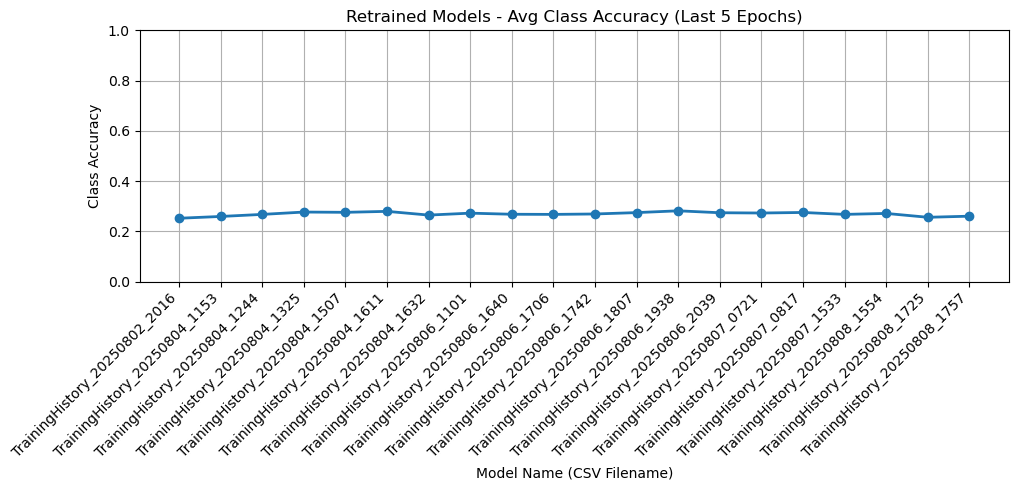

Exception in thread Thread-9 (run_comparison_task):
Traceback (most recent call last):
  File "C:\Users\sagar\AppData\Local\Temp\ipykernel_18336\1392088198.py", line 62, in run_comparison_task
  File "C:\Users\sagar\anaconda3\envs\tf_keras3\lib\site-packages\keras\src\utils\traceback_utils.py", line 122, in error_handler
    raise e.with_traceback(filtered_tb) from None
  File "C:\Users\sagar\AppData\Local\Temp\ipykernel_18336\1392088198.py", line 32, in write
  File "C:\Users\sagar\AppData\Local\Temp\ipykernel_18336\1392088198.py", line 23, in update_log
  File "C:\Users\sagar\anaconda3\envs\tf_keras3\lib\tkinter\__init__.py", line 3782, in insert
    self.tk.call((self._w, 'insert', index, chars) + args)
RuntimeError: main thread is not in main loop

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\sagar\AppData\Local\Temp\ipykernel_18336\1392088198.py", line 87, in run_comparison_task
  File "C:\Users\sagar\AppD

In [59]:
root = tk.Tk()
# root.state('zoomed')
# root.rowconfrigure(0,weight=1)

# root.columnconfrigure(0,weight=1)
root.title("Human in Loop")
root.eval("tk::PlaceWindow . center")


frame1 = tk.Frame(root, width=500, height=600, bg=bg_colour)
frame2 = tk.Frame(root, width=500, height=600,bg=bg_colour)
frame3 = tk.Frame(root, bg=bg_colour)

for frame in (frame1, frame2, frame3):
    frame.grid(row=0, column=0, sticky="nesw")

load_frame1()
root.mainloop()